## Code to investigate the PLOT impact of the SEED based on selected number of background samples

In [1]:
region_name = "CONUS"
experiment = "EX29"
week_lead = 1
ref_source = "GEFSv12"

checkpoint = f'checkpoints/{region_name}/Wk{week_lead}/Wk{week_lead}_{experiment}_regular_RZSM' if \
ref_source == 'GEFSv12' else f'checkpoints/{region_name}/Wk{week_lead}/Wk{week_lead}_{experiment}_ECMWF_regular_RZSM'
print(checkpoint)

checkpoints/CONUS/Wk1/Wk1_EX29_regular_RZSM


In [2]:
#feature channel names (predictors)
with open(f"channel_list_information/Wk{week_lead}/{experiment}_RZSM_channel_list.txt") as f:
    names = [line.strip() for line in f]
names = [s.split()[-1] for s in names]
print(names)

['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'pwat_ref_lead1', 'spfh_ref_lead1', 'tmax_ref_lead1', 'diff_temp_ref_lead1', 'z200_ref_lead1']


In [8]:
plot_dir = 'Outputs/shap'
os.makedirs(plot_dir, exist_ok=True)

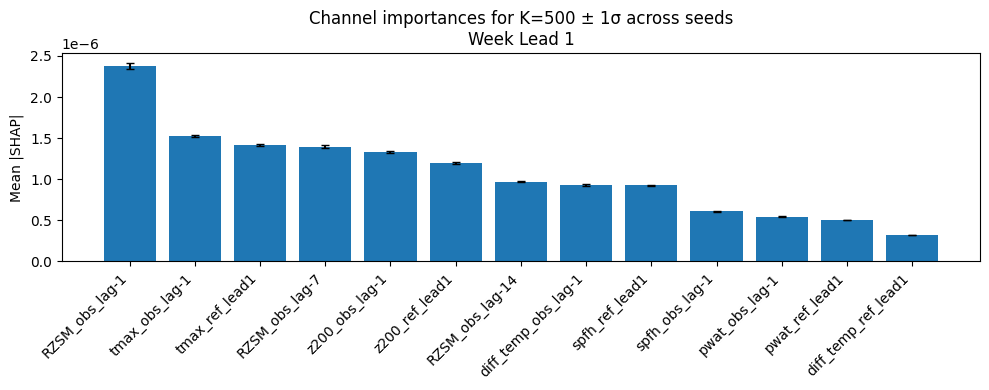

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

Ks            = [10,25,50,100,250,500]
SEEDS         = [0, 1, 2, 3, 225]
base_dir      = f"Data/shap_tests/Wk{week_lead}"
channel_names = names   # list of length C
C             = len(channel_names)

# --- 1) Load all mean_abs into an array of shape (n_seeds, n_Ks, C) ---
mean_abs_runs = np.zeros((len(SEEDS), len(Ks), C))
for i, seed in enumerate(SEEDS):
    for j, K in enumerate(Ks):
        run_dir = os.path.join(base_dir, f"seed{seed:03d}_K{K}_gradient_explainer")
        mean_abs_runs[i, j, :] = np.load(os.path.join(run_dir, "mean_abs.npy"))

Kplot = 500

# --- 2) Bar‐chart with error bars for a single K ---
k0 = Ks.index(Kplot)
means = mean_abs_runs[:, k0, :].mean(axis=0)
stds  = mean_abs_runs[:, k0, :].std(axis=0)

# --- Sort in descending order of mean SHAP values ---
sorted_indices = np.argsort(means)[::-1]
means_sorted = means[sorted_indices]
stds_sorted = stds[sorted_indices]
channel_names_sorted = [channel_names[i] for i in sorted_indices]

# --- Plot ---
plt.figure(figsize=(10,4))
x = np.arange(C)
plt.bar(x, means_sorted, yerr=stds_sorted, capsize=3)
plt.xticks(x, channel_names_sorted, rotation=45, ha="right")
plt.ylabel("Mean |SHAP|")
plt.title(f"Channel importances for K={Kplot} ± 1σ across seeds\nWeek Lead 1")
plt.tight_layout()
plt.savefig(f"{plot_dir}/channel_importances_all_seeds_K{Kplot}.png", dpi=300, format='png', bbox_inches='tight')
plt.show()

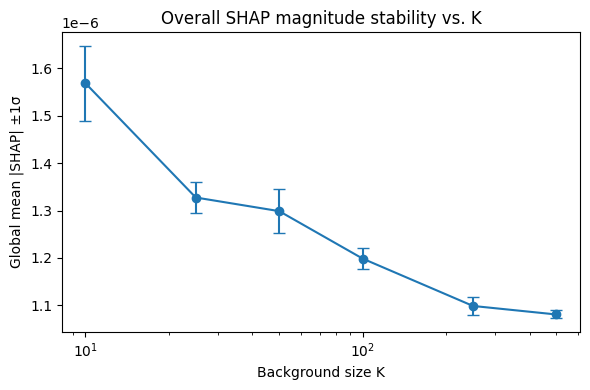

In [5]:


# --- 3) Global stability vs K: mean ± std over seeds & channels ---
#    collapse channels first, then seeds
global_means = mean_abs_runs.mean(axis=2).mean(axis=0)  # shape (len(Ks),)
global_stds  = mean_abs_runs.mean(axis=2).std(axis=0)

plt.figure(figsize=(6,4))
plt.errorbar(Ks, global_means, yerr=global_stds, marker='o', capsize=4)
plt.xscale('log')
plt.xlabel("Background size K")
plt.ylabel("Global mean |SHAP| ±1σ")
plt.title("Overall SHAP magnitude stability vs. K")
plt.tight_layout()
plt.show()


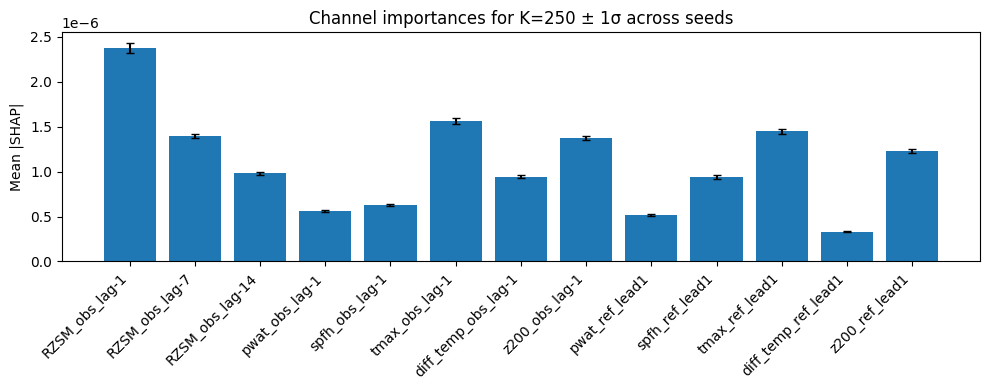

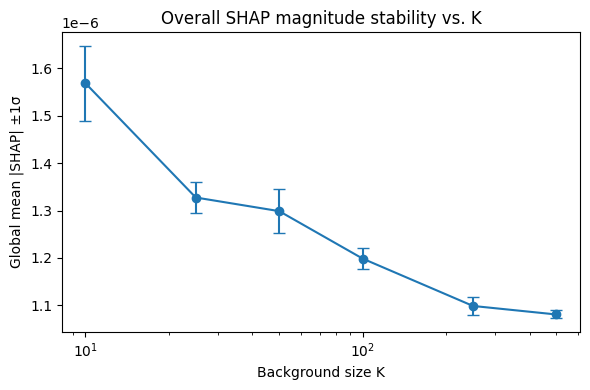

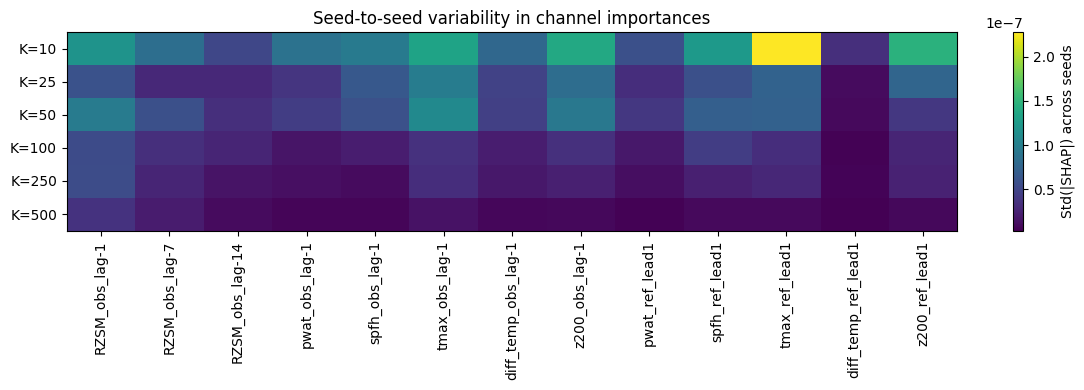

In [8]:

# --- 4) Heatmap of per‐channel SD across seeds, for each K ---
sd_runs = mean_abs_runs.std(axis=0)  # shape (len(Ks), C)

plt.figure(figsize=(12,4))
im = plt.imshow(sd_runs, aspect='auto', interpolation='nearest')
plt.colorbar(im, label="Std(|SHAP|) across seeds")
plt.yticks(range(len(Ks)), [f"K={K}" for K in Ks])
plt.xticks(range(C), channel_names, rotation=90)
plt.title("Seed‐to‐seed variability in channel importances")
plt.tight_layout()
plt.show()
